# PS: P-Spline with IWLS proposals and constant weights

## Setup and Imports

In [1]:
import jax.numpy as jnp
import liesel.goose as gs
import liesel.model as lsl
import numpy as np
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel_gam as gam
from liesel_gam.iwls_proposals import IWLSProposal, IWLSWeights


Warning message:
package ‘arrow’ was built under R version 4.5.2 


In [2]:
from scipy import stats

rng = np.random.default_rng(1)
x = rng.uniform(-2, 2, 200)

log_sigma = -1.0 + 0.3 * (
    0.5 * x + 15 * stats.norm.pdf(2 * (x - 0.2)) - stats.norm.pdf(x + 0.4)
)
mu = -x + np.pi * np.sin(np.pi * x)
y = mu + jnp.exp(log_sigma) * rng.normal(0.0, 1.0, 200)

df = pd.DataFrame({"y": y, "x": x})

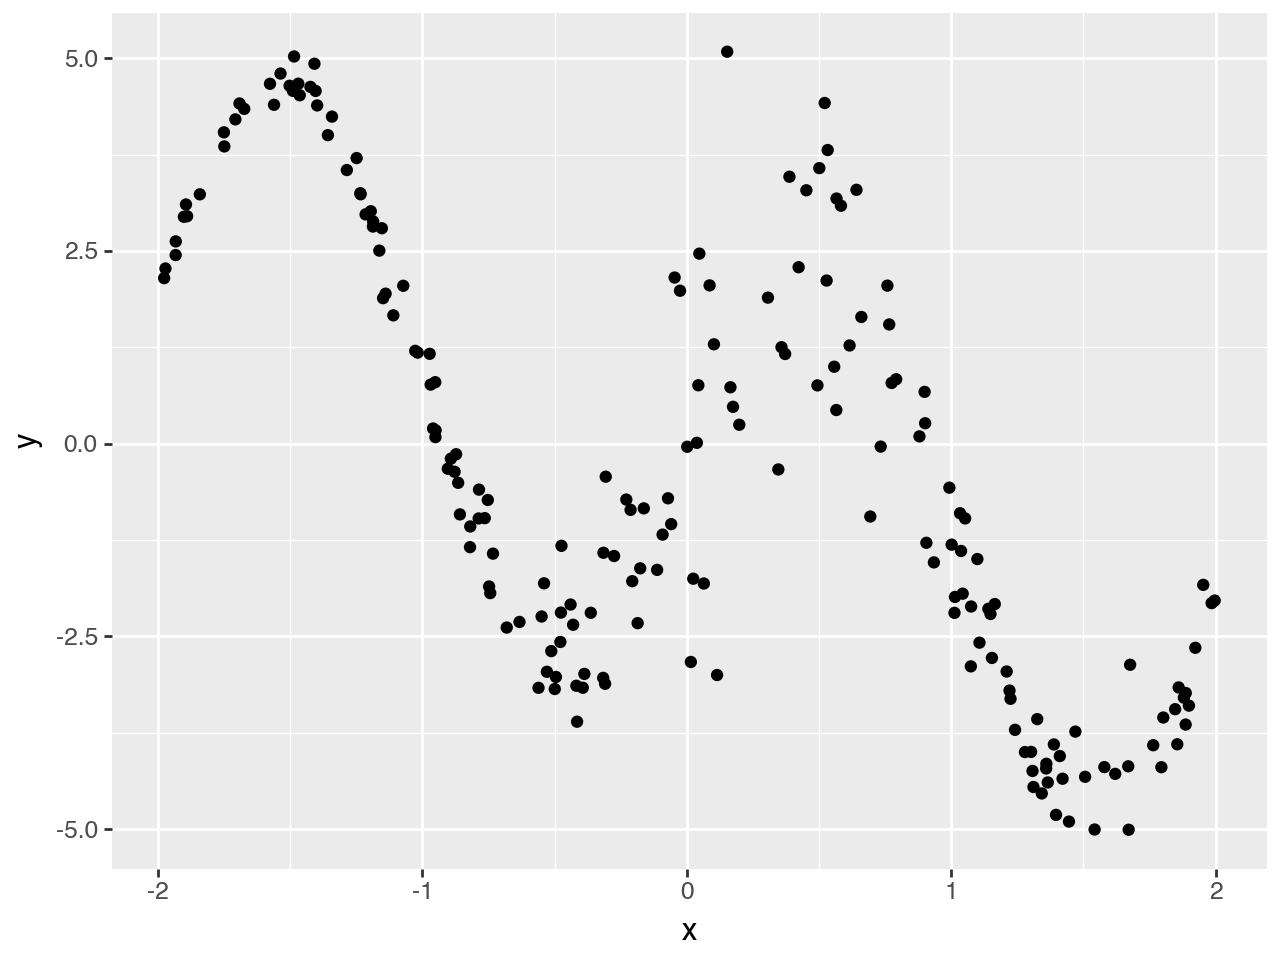

In [3]:
(p9.ggplot(df) + p9.geom_point(p9.aes("x", "y")))

## Model Definition

### Setup response model

In [4]:
loc = gam.AdditivePredictor("loc")
scale = gam.AdditivePredictor("scale", inv_link=jnp.exp)


y = lsl.Var.new_obs(
    value=df.y.to_numpy(),
    distribution=lsl.Dist(tfd.Normal, loc=loc, scale=scale),
    name="y",
)


registry = gam.PandasRegistry(df)
tbl = gam.TermBuilder(registry, prefix_names_by="loc.")
tbs = gam.TermBuilder(registry, prefix_names_by="scale.")

loc_ps = tbl.ps("x", k=20)
scale_ps = tbs.ps("x", k=20)

loc += loc_ps
scale += scale_ps


### Build model and configure IWLS proposals

This version configures the general `IWLSProposal` explicitly with constant
working weights. For production code, the bulk helper
`IWLSProposal.set_mcmc_specs()` can assign this pattern to all supported structured
terms in a predictor.

The constant weights for the location predictor are theoretically wrong in this
heteroscedastic Gaussian model: the Gaussian-location curvature should depend on
the observation scale through `1 / scale**2`. We use constant weights here as an
intentional comparison case. Because the location proposal is poorly matched to
the target geometry, the sampler is expected to be visibly inefficient.


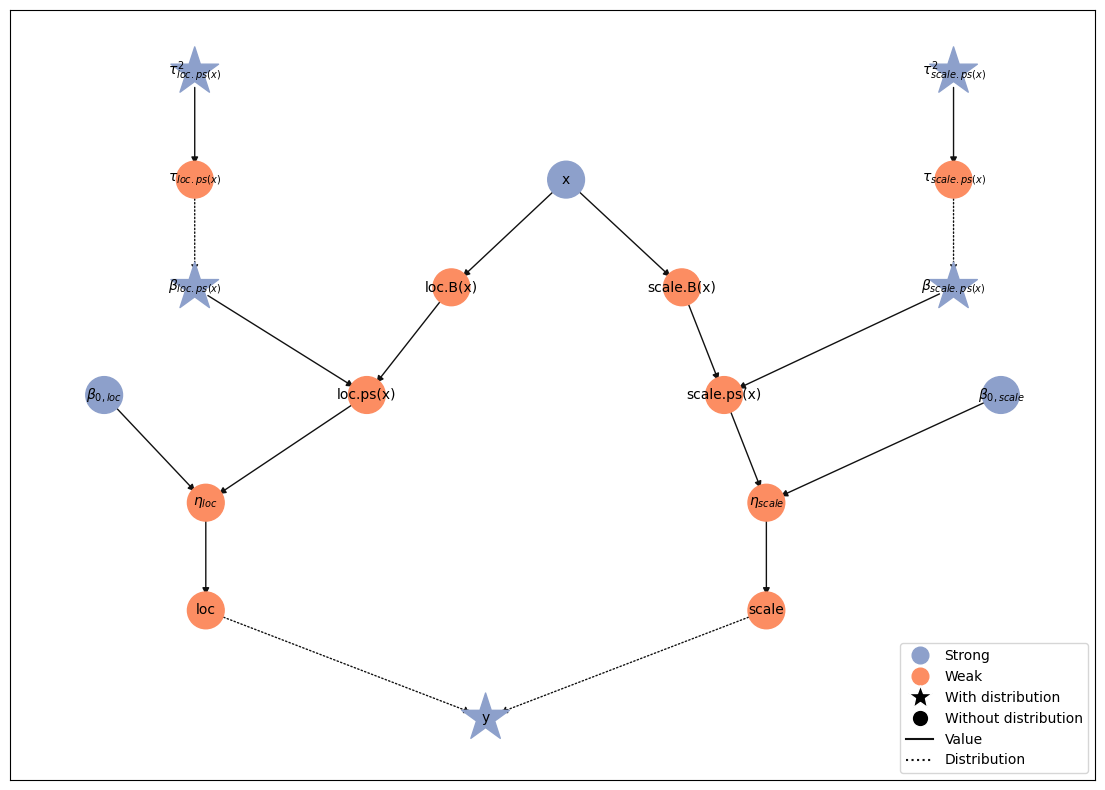

In [5]:
model = lsl.Model([y])

constant_weights = IWLSWeights.constant()

# Bulk alternative:
# IWLSProposal.set_mcmc_specs(loc, constant_weights, fallback_chol_info=None)
# IWLSProposal.set_mcmc_specs(scale, constant_weights, fallback_chol_info=None)
#
# Note: constant weights are intentionally used for loc_ps here, but they are not
# the correct Gaussian-location IWLS weights for this model. The correct weights
# depend on the observation scale via 1 / scale**2, so this proposal is expected
# to sample the location coefficients inefficiently.
loc_iwls = IWLSProposal.from_term(loc_ps, constant_weights)
scale_iwls = IWLSProposal.from_term(scale_ps, constant_weights)

loc_ps.coef.inference = gs.MCMCSpec(
    kernel=loc_iwls.kernel_factory(),
    kernel_kwargs={"fallback_chol_info": None, "da_tune_step_size": True},
)
scale_ps.coef.inference = gs.MCMCSpec(
    kernel=scale_iwls.kernel_factory(),
    kernel_kwargs={"fallback_chol_info": None, "da_tune_step_size": True},
)

model.plot_vars()


## Run MCMC

In [6]:
eb = gs.LieselMCMC(model).get_engine_builder(seed=1, num_chains=4)

eb.add_adaptation(3000)
eb.add_posterior(10_000, thinning=10)

engine = eb.build()
engine.sample_all_epochs()
results = engine.get_results()

liesel.goose.builder - WARNING - No jitter functions provided for position keys '$\\beta_{loc.ps(x)}$', '$\\beta_{scale.ps(x)}$', '$\\tau_{loc.ps(x)}^2$', '$\\beta_{0,loc}$', '$\\tau_{scale.ps(x)}^2$', '$\\beta_{0,scale}$'. The initial values for these keys won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 300 transitions, 25 jitted together
100%|████████████████████████████████████████| 12/12 [00:02<00:00,  4.34chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|████████████████████████████████████████| 1/1 [00:00<00:00, 1008.97chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 50 transitions, 25 jitted together
100%|████████████████████████████████████████| 2/2 [00:00<00:00, 1614.13chunk/s]
liesel.goose.e

### MCMC summary

In [7]:
summary = gs.Summary(results)
summary

Parameter summary:

                                 kernel      mean        sd    q_0.05  \
parameter              index                                            
$\beta_{0,loc}$        ()     kernel_03 -0.318953  0.059867 -0.420556   
$\beta_{0,scale}$      ()     kernel_05 -0.627421  0.053403 -0.713524   
$\beta_{loc.ps(x)}$    (0,)   kernel_00  0.138799  0.314438 -0.376331   
                       (1,)   kernel_00 -0.170990  0.300314 -0.670901   
                       (2,)   kernel_00  0.149221  0.286864 -0.311649   
                       (3,)   kernel_00  0.132754  0.273946 -0.321713   
                       (4,)   kernel_00 -0.275244  0.279493 -0.744090   
                       (5,)   kernel_00  0.046393  0.283249 -0.395762   
                       (6,)   kernel_00 -0.004452  0.247720 -0.403563   
                       (7,)   kernel_00  0.113754  0.219887 -0.243778   
                       (8,)   kernel_00  0.075326  0.217482 -0.274212   
                       (9,)   kernel_00  0.074333  0.184456 -0.221513   
                       (10,)  kernel_00  0.088493  0.175250 -0.207058   
                       (11,)  kernel_00 -0.034092  0.134048 -0.258352   
                       (12,)  kernel_00  0.080127  0.109799 -0.097940   
                       (13,)  kernel_00 -0.087800  0.082816 -0.218919   
                       (14,)  kernel_00  1.230851  0.064741  1.123913   
                       (15,)  kernel_00  0.021985  0.040492 -0.042605   
                       (16,)  kernel_00 -0.014312  0.021135 -0.048888   
                       (17,)  kernel_00  0.009053  0.008765 -0.004792   
                       (18,)  kernel_00 -0.424003  0.030437 -0.473124   
$\beta_{scale.ps(x)}$  (0,)   kernel_01  0.011534  0.078040 -0.110262   
                       (1,)   kernel_01 -0.011119  0.078801 -0.143535   
                       (2,)   kernel_01 -0.008842  0.077130 -0.131934   
                       (3,)   kernel_01 -0.003812  0.075720 -0.128289   
                       (4,)   kernel_01  0.004522  0.079124 -0.124442   
                       (5,)   kernel_01 -0.006081  0.076904 -0.132169   
                       (6,)   kernel_01  0.026037  0.076976 -0.089048   
                       (7,)   kernel_01  0.032318  0.072536 -0.079351   
                       (8,)   kernel_01  0.011374  0.073199 -0.107492   
                       (9,)   kernel_01 -0.014231  0.068086 -0.129019   
                       (10,)  kernel_01  0.013735  0.068993 -0.096363   
                       (11,)  kernel_01  0.008055  0.064165 -0.093066   
                       (12,)  kernel_01  0.067754  0.060488 -0.025846   
                       (13,)  kernel_01 -0.065862  0.051228 -0.150993   
                       (14,)  kernel_01  0.059849  0.041472 -0.007302   
                       (15,)  kernel_01  0.079168  0.029491  0.031552   
                       (16,)  kernel_01  0.005048  0.017016 -0.022678   
                       (17,)  kernel_01 -0.041860  0.007115 -0.053435   
                       (18,)  kernel_01  0.128855  0.027879  0.082498   
$\tau_{loc.ps(x)}^2$   ()     kernel_02  0.139593  0.062135  0.068318   
$\tau_{scale.ps(x)}^2$ ()     kernel_04  0.005992  0.004463  0.001998   

                                 q_0.5    q_0.95  sample_size     ess_bulk  \
parameter              index                                                 
$\beta_{0,loc}$        ()    -0.317438 -0.221847         4000   132.351763   
$\beta_{0,scale}$      ()    -0.628435 -0.539809         4000  2830.099109   
$\beta_{loc.ps(x)}$    (0,)   0.142727  0.653305         4000   156.115109   
                       (1,)  -0.163833  0.302399         4000   129.838134   
                       (2,)   0.142788  0.648678         4000   146.000067   
                       (3,)   0.144998  0.567900         4000   123.440658   
                       (4,)  -0.275205  0.180028         4000   158.095623   
                       (5,)   0.037961  0.537194         4000   1

### MCMC trace plots

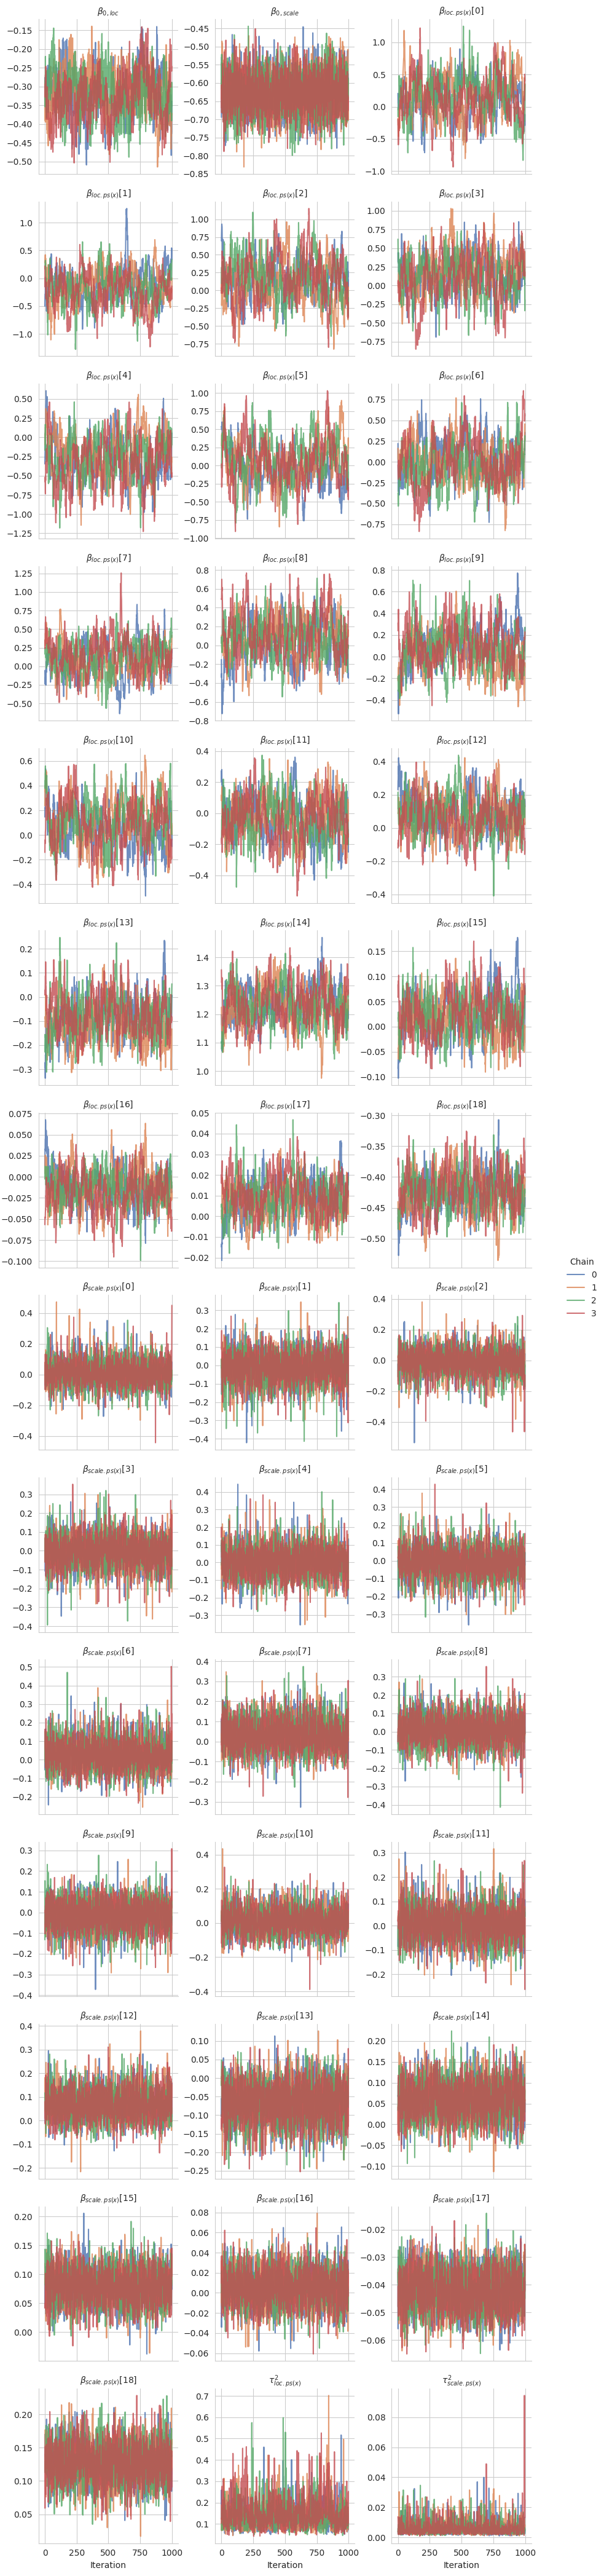

In [8]:
gs.plot_trace(results)

## Predictions

In [9]:
samples = results.get_posterior_samples()

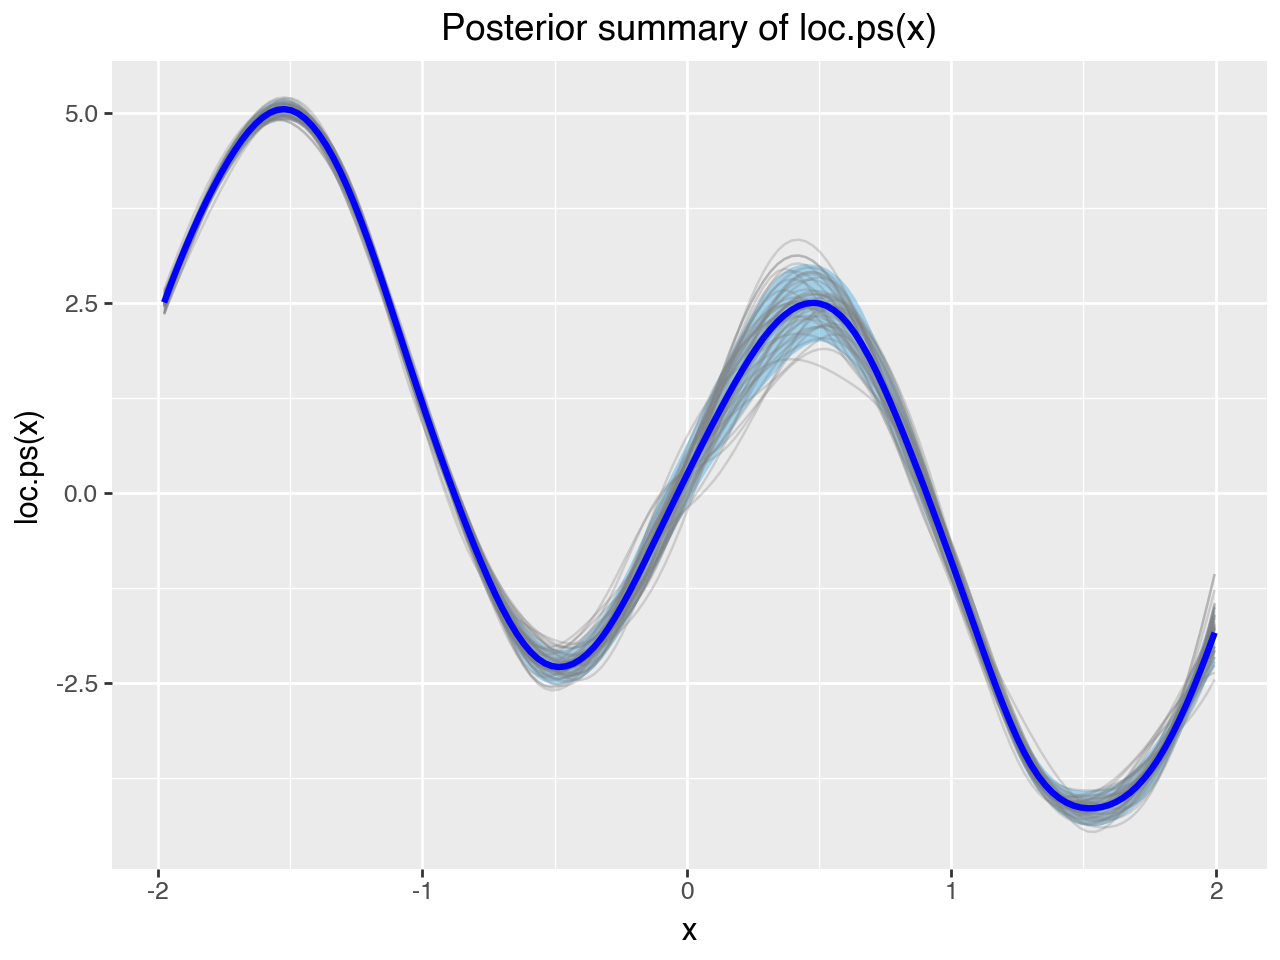

In [10]:
gam.plot_1d_smooth(term=model.vars["loc.ps(x)"], samples=samples)

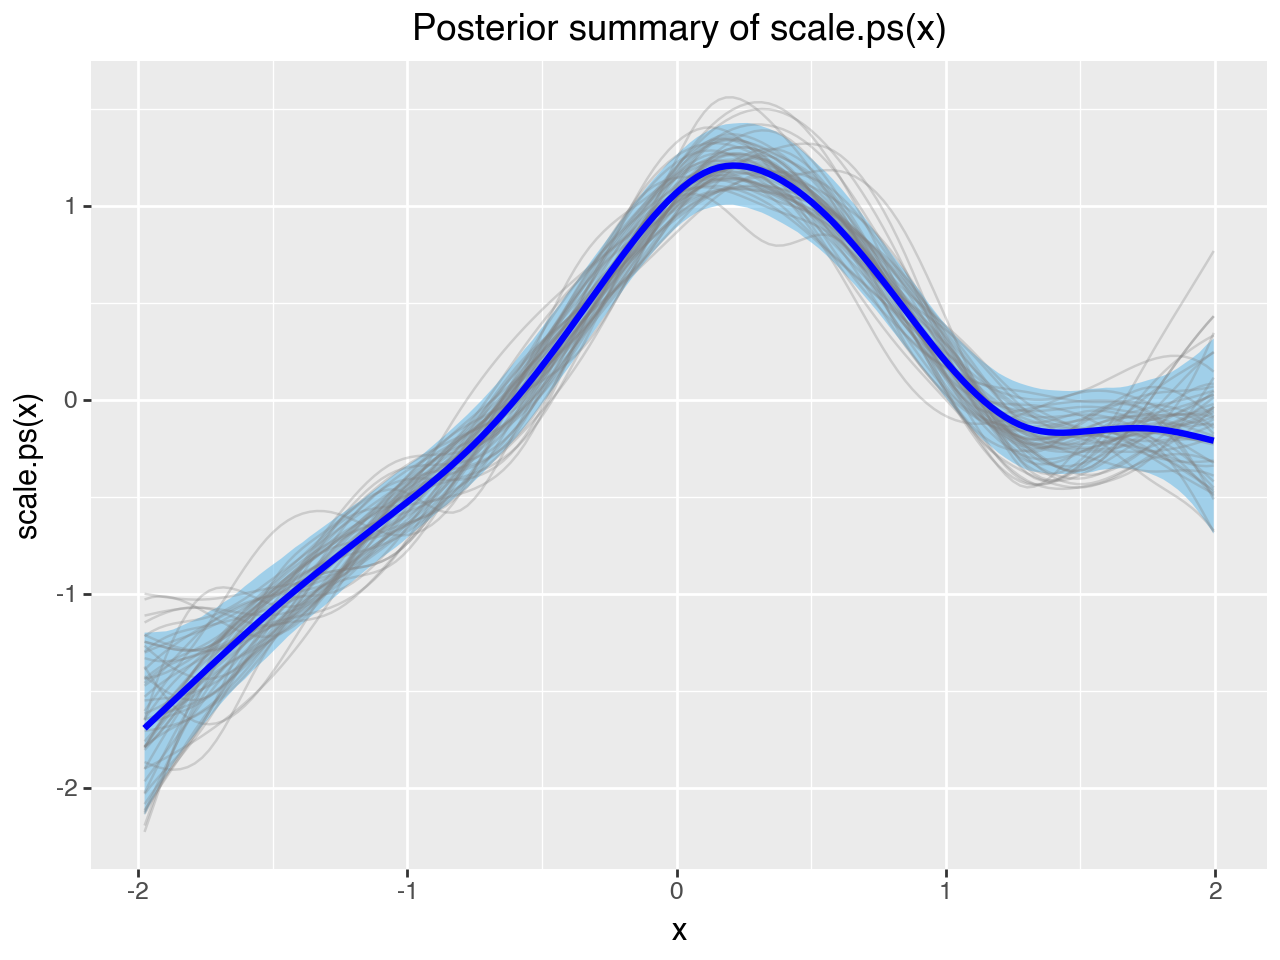

In [11]:
gam.plot_1d_smooth(term=model.vars["scale.ps(x)"], samples=samples)

### Predict variables at new x values

In [12]:
x_grid = jnp.linspace(df.x.min(), df.x.max(), 300)

predictions = model.predict(
    samples=samples,
    predict=["loc.ps(x)", "scale.ps(x)", "loc", "scale"],
    newdata={"x": x_grid},
)

predictions_summary = gs.SamplesSummary(predictions).to_dataframe().reset_index()
predictions_summary["x"] = np.tile(x_grid, len(predictions))

### Plot parameters as functions of covariate

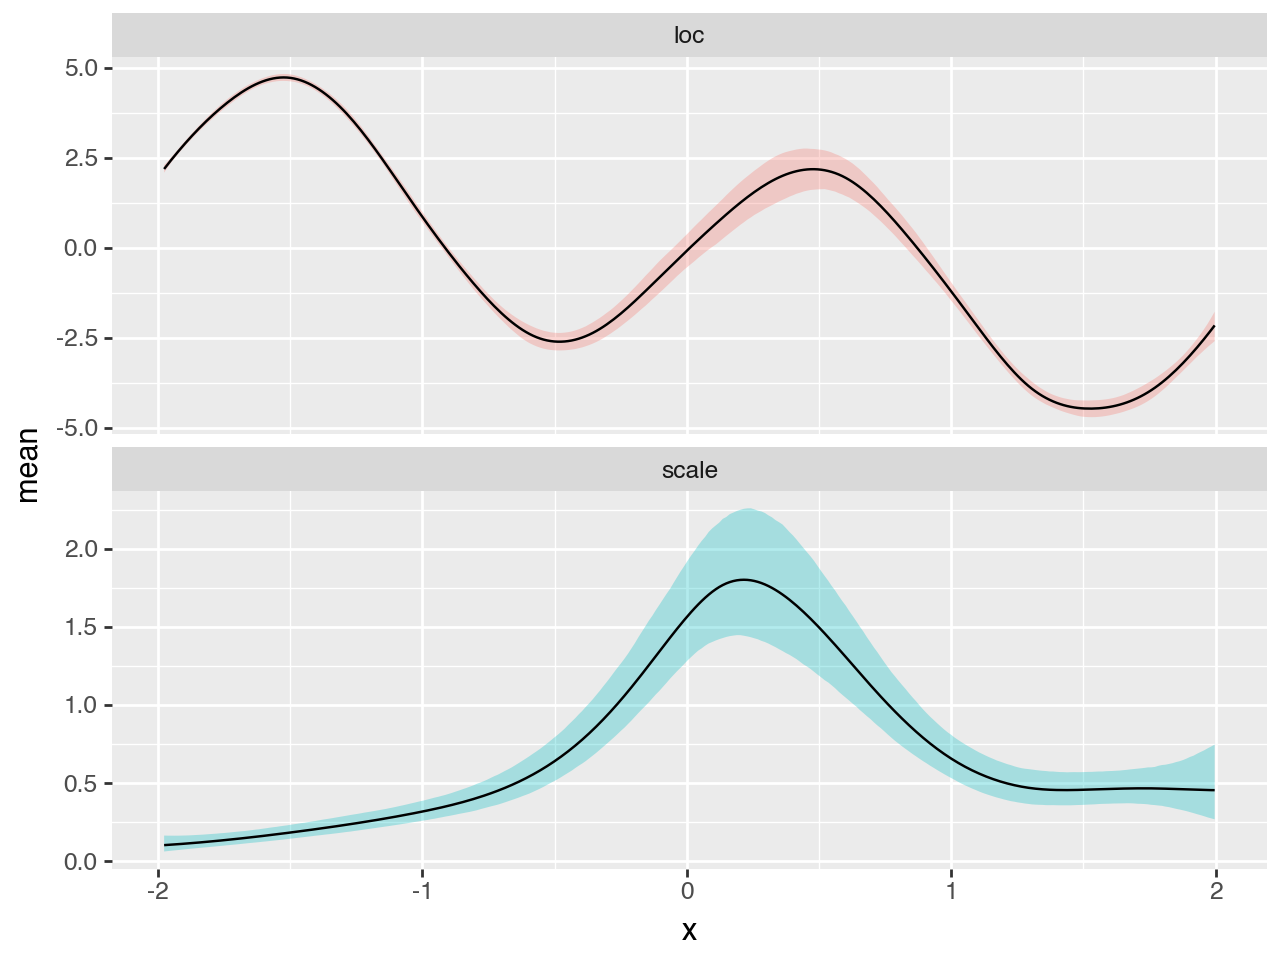

In [13]:
select = predictions_summary["variable"].isin(["loc", "scale"])
(
    p9.ggplot(predictions_summary[select])
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95", fill="variable"), alpha=0.3
    )
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.facet_wrap("~variable", scales="free_y", ncol=1)
    + p9.guides(fill="none")
)

### Plot fitted location with raw data

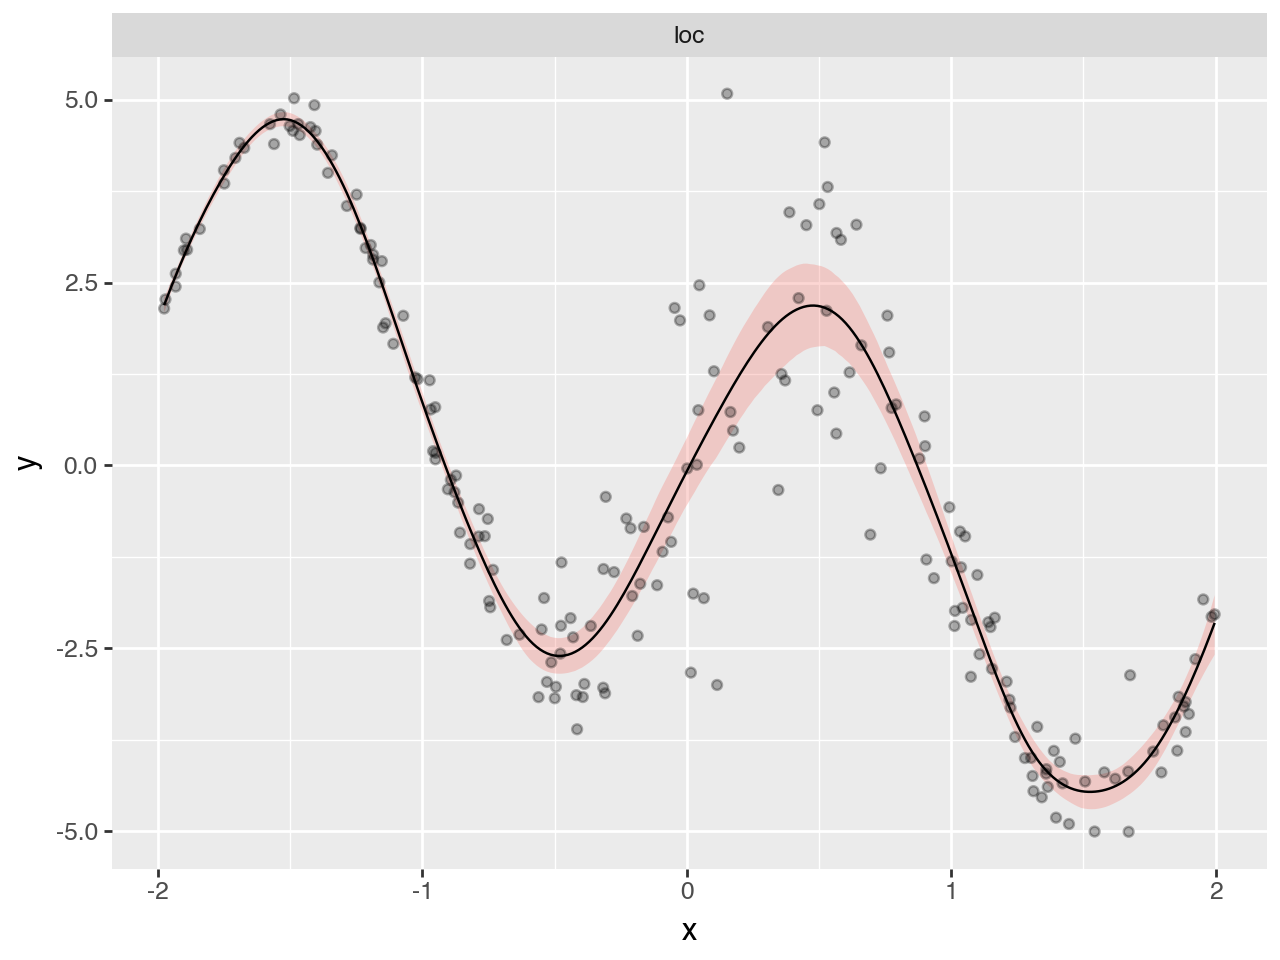

In [14]:
select = predictions_summary["variable"].isin(["loc"])
(
    p9.ggplot(predictions_summary[select])
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95", fill="variable"), alpha=0.3
    )
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.facet_wrap("~variable", scales="free_y", ncol=1)
    + p9.guides(fill="none")
)

### Posterior predictive distribution

In [15]:
select = predictions_summary["variable"].isin(["loc", "scale"])
mu_sigma_df = (
    predictions_summary[select][["variable", "mean", "x"]]
    .pivot(index="x", columns=["variable"], values="mean")
    .reset_index()
)

mu_sigma_df["low"] = mu_sigma_df["loc"] - mu_sigma_df["scale"]
mu_sigma_df["high"] = mu_sigma_df["loc"] + mu_sigma_df["scale"]
mu_sigma_df

variable,x,loc,scale,low,high
0,-1.976702,2.192762,0.102820,2.089941,2.295582
1,-1.963415,2.318184,0.104281,2.213903,2.422465
2,-1.950128,2.440965,0.105793,2.335172,2.546758
3,-1.936841,2.561075,0.107356,2.453719,2.668431
4,-1.923554,2.678515,0.108970,2.569545,2.787485
...,...,...,...,...,...
295,1.942956,-2.646202,0.456245,-3.102447,-2.189957
296,1.956243,-2.526801,0.455694,-2.982495,-2.071108
297,1.969530,-2.404542,0.455249,-2.859791,-1.949293
298,1.982817,-2.279558,0.454926,-2.734484,-1.824632


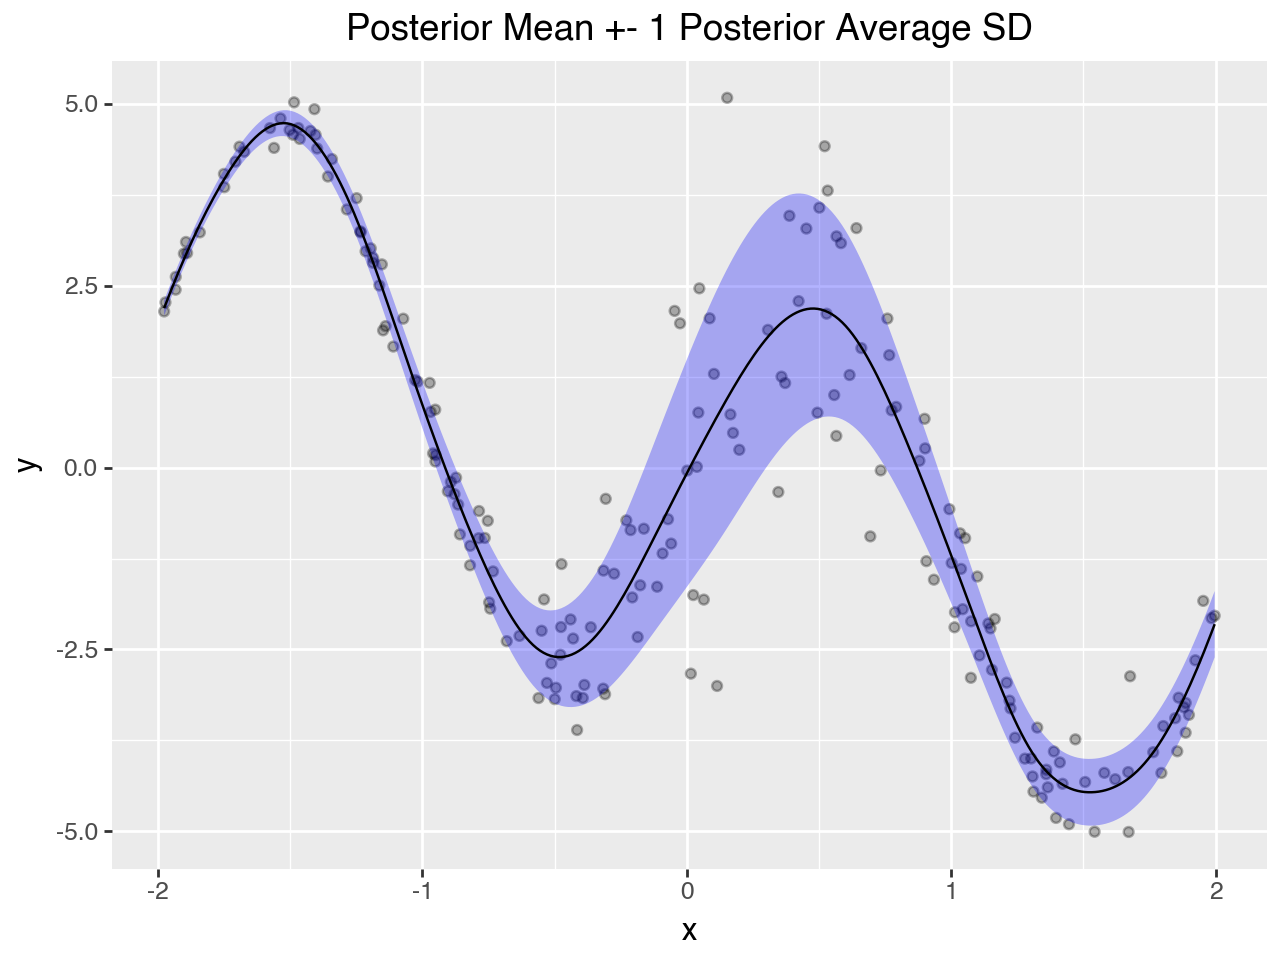

In [16]:
(
    p9.ggplot()
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_ribbon(
        p9.aes("x", ymin="low", ymax="high"),
        alpha=0.3,
        fill="blue",
        data=mu_sigma_df,
    )
    + p9.geom_line(p9.aes("x", "loc"), data=mu_sigma_df)
    + p9.labs(title="Posterior Mean +- 1 Posterior Average SD")
    + p9.guides(fill="none")
)

### Sample from posterior predictive distribution

In [17]:
import jax

ppsamples = model.sample(shape=(), seed=jax.random.key(1), posterior_samples=samples)

ppsamples["y"].shape

(4, 1000, 200)

In [18]:
# summarise ppsamples
ppsamples_summary = gs.SamplesSummary(ppsamples).to_dataframe().reset_index()

# add covariate to df
ppsamples_summary["x"] = df["x"].to_numpy()

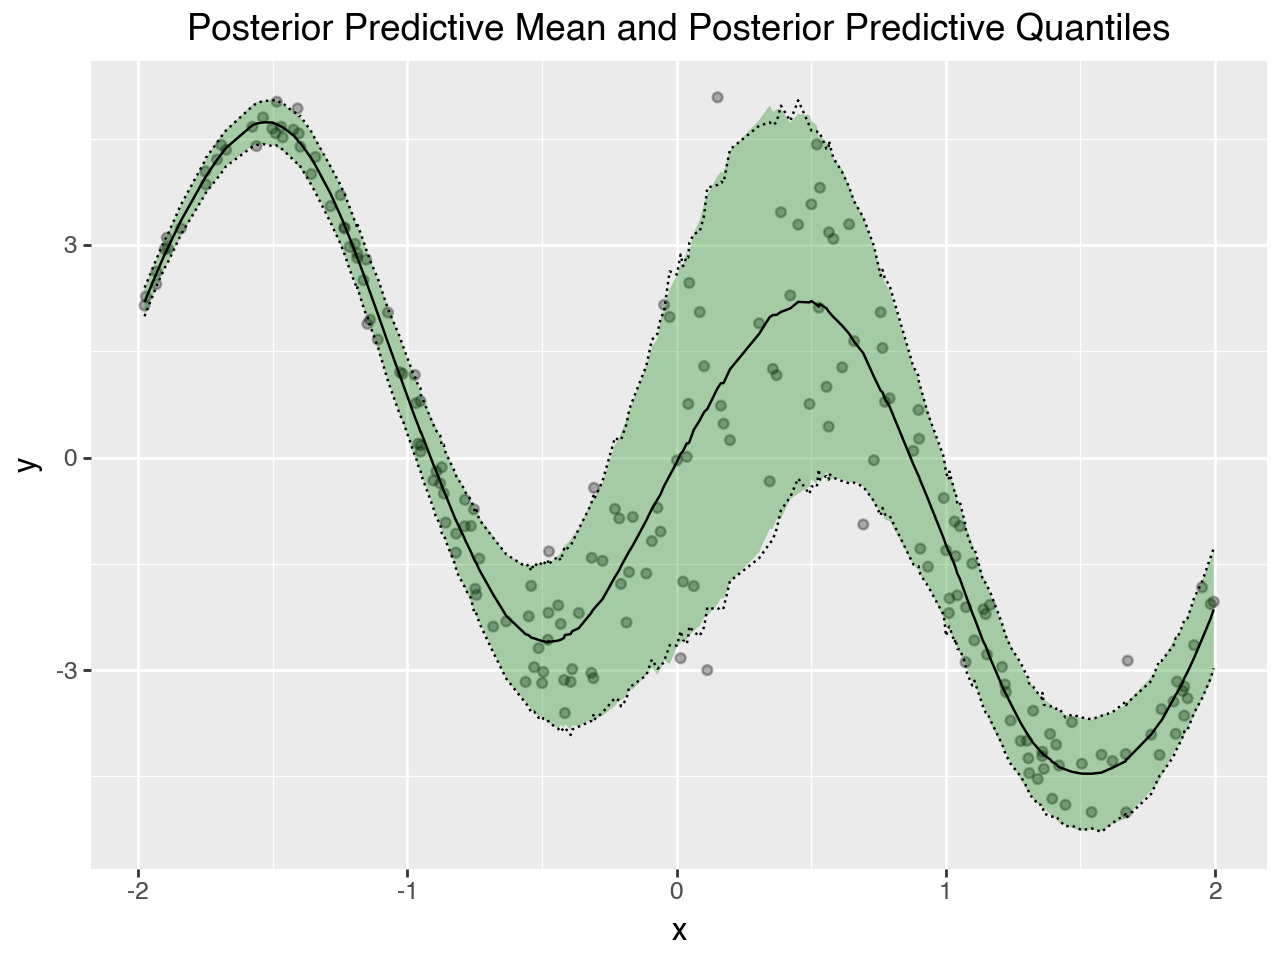

In [19]:
(
    p9.ggplot(ppsamples_summary)
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95"),
        alpha=0.3,
        fill="green",
    )
    + p9.geom_line(p9.aes("x", "hdi_low"), linetype="dotted")
    + p9.geom_line(p9.aes("x", "hdi_high"), linetype="dotted")
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.labs(title="Posterior Predictive Mean and Posterior Predictive Quantiles")
    + p9.guides(fill="none")
)